# H2分子VMC方法对比：QNN vs FFNN

本notebook对比两种不同的神经网络方法用于H2分子的变分蒙特卡洛(VMC)计算：
- **QNN (Quantum Neural Network)**: 使用PennyLane实现的量子神经网络
- **FFNN (Feed-Forward Neural Network)**: 传统的前馈神经网络

两种方法都使用NetKet框架进行VMC计算，并与Hartree-Fock和FCI能量进行对比。

## 1. 环境设置和分子定义

In [1]:
import netket as nk
import numpy as np
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
import jax
import jax.numpy as jnp
import pennylane as qml
from flax import nnx
from functools import partial

jax.config.update("jax_enable_x64", True)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 设置H2分子的几何构型
bond_length = 1.74  # H2平衡键长（埃）
geometry = [
    ('H', (0., 0., 0.)),
    ('H', (bond_length, 0., 0.)),
]

# 创建分子对象，使用STO-3G基组
mol = gto.M(atom=geometry, basis='STO-3G')

# 进行Hartree-Fock计算
mf = scf.RHF(mol).run(verbose=0)
E_hf = mf.e_tot
print(f"Hartree-Fock能量: {E_hf:.8f} Ha")

# 进行FCI计算作为参考
cisolver = fci.FCI(mf)
E_fci, fcivec = cisolver.kernel()
print(f"FCI能量: {E_fci:.8f} Ha")

# 使用NetKet创建哈密顿量
ha = nkx.operator.from_pyscf_molecule(mol)

Hartree-Fock能量: -0.84390759 Ha
FCI能量: -0.96730577 Ha


In [3]:
# 定义希尔伯特空间
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=2,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(1, 1)  # 每种自旋的电子数
)

# 创建采样器 - 使用费米子跳跃采样器
g = nk.graph.Graph(edges=[(0,1),(2,3)])
sampler = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

## 2. QNN方法实现

### 2.1 定义量子神经网络

In [4]:
def quantum_neural_network(x, params, n_qubits, n_layers):
    """
    兼容Batch的量子电路核心逻辑
    - x: 输入张量，形状为 (batch_size, n_qubits)
    - params: 量子电路参数，形状为 (n_layers, 2 * n_qubits)
    """
    x = jnp.atleast_2d(x)
    if x.shape[-1] != n_qubits:
        raise ValueError(f"输入特征维度需为{n_qubits}，当前为{x.shape[-1]}")
    
    # 数据编码：向量化RX门
    for i in range(n_qubits):
        qml.RX(x[:, i] * jnp.pi, wires=i)
    
    # 变分层：向量化旋转/纠缠门
    for layer in range(n_layers):
        # 纠缠层（CNOT无参数，Batch不影响）
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.Barrier(wires=range(n_qubits))
        # 旋转层：参数向量化，自动适配Batch
        for i in range(n_qubits):
            qml.RX(params[layer, 2*i], wires=i)
            qml.RZ(params[layer, 2*i+1], wires=i)
    
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [5]:
def qnn_circuit(n_qubits: int, n_layers: int):
    dev = qml.device('default.qubit', wires=n_qubits)
    pqc_node = qml.QNode(func=quantum_neural_network, device=dev, interface='jax')
    qnn_node_circuit = partial(pqc_node, n_qubits=n_qubits, n_layers=n_layers)
    return qnn_node_circuit

In [6]:
class QNNLinear(nnx.Module):
    def __init__(self, rngs: nnx.Rngs, n_qubits: int, n_layer: int):
        key = rngs.params()
        self.n_qubits, self.n_layer = n_qubits, n_layer
        self.qnn_params = nnx.Param(jax.random.normal(key, (self.n_layer, 2*self.n_qubits), dtype=jnp.float32))
        self.qnn_layer = partial(qnn_circuit, n_qubits=self.n_qubits, n_layers=self.n_layer)()
        self.Linear = nnx.Linear(in_features=self.n_qubits, out_features=self.n_qubits, use_bias=False, rngs=rngs)
        
    def __call__(self, s: np.array):
        s = jnp.array(s, dtype=jnp.float32)
        qnn_output = self.qnn_layer(x=s, params=self.qnn_params)
        qnn_output = jnp.stack(qnn_output, axis=1)
        qnn_output = jnp.array(qnn_output, dtype=jnp.float32)
        y = self.Linear(qnn_output)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)

class QNN_Hybrid(nnx.Module):
    def __init__(self, rngs_real: nnx.Rngs, rngs_imag: nnx.Rngs, n_qubits: int, n_layer: int):
        self.qnn_real = QNNLinear(rngs_real, n_qubits, n_layer)
        self.qnn_imag = QNNLinear(rngs_imag, n_qubits, n_layer)
        
    def __call__(self, s: np.array):
        real = self.qnn_real(s)
        imag = self.qnn_imag(s)
        return real + 1j*imag

### 2.2 QNN训练

In [7]:
# 初始化QNN模型
n_qubits = 4
n_layer = 2
qnn_model = QNN_Hybrid(
    rngs_real=nnx.Rngs(params=0),
    rngs_imag=nnx.Rngs(params=1),
    n_qubits=n_qubits,
    n_layer=n_layer
)

# 创建变分状态
qnn_vstate = nk.vqs.MCState(sampler, qnn_model, n_samples=1008)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
qnn_gs = nk.driver.VMC(ha, opt, variational_state=qnn_vstate, preconditioner=sr)

# 运行优化
qnn_exp_name = "h2_molecule_qnn_hybrid"
print("开始QNN训练...")

开始QNN训练...


In [8]:
qnn_gs.run(200, out=qnn_exp_name)
print("QNN训练完成！")

100%|██████████| 200/200 [01:54<00:00,  1.74it/s, Energy=-0.96623+0.00000j ± 0.00024 [σ²=0.00006, R̂=1.0067]]

QNN训练完成！


## 3. FFNN方法实现

### 3.1 定义前馈神经网络

In [9]:
class FFN(nnx.Module):
    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        """
        构建单隐藏层前馈神经网络
        
        Args:
            N: 输入节点数（自旋链中的自旋数）
            alpha: 隐藏层密度。隐藏层将有 N*alpha 个节点
            rngs: 随机数生成器种子
        """
        self.alpha = alpha
        
        # 定义一个线性（密集）层，输出节点数为输入节点数的 alpha 倍
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs, param_dtype=complex)
    
    def __call__(self, x: jax.Array):
        # 对输入应用线性层
        y = self.linear(x)
        
        # 非线性激活函数：简单的 ReLU
        y = nnx.relu(y)
        
        # 对输出求和
        return jnp.sum(y, axis=-1)

### 3.2 FFNN训练

In [39]:
# 初始化FFNN模型
N = 4
ffnn_model = FFN(N=N, alpha=1, rngs=nnx.Rngs(2))

# 创建变分状态
ffnn_vstate = nk.vqs.MCState(sampler, ffnn_model, n_discard_per_chain=10, n_samples=512)

# 设置优化器
opt = nk.optimizer.Sgd(learning_rate=0.05)
sr = nk.optimizer.SR(diag_shift=0.01)

# 创建VMC驱动器
ffnn_gs = nk.driver.VMC(ha, opt, variational_state=ffnn_vstate, preconditioner=sr)

# 运行优化
ffnn_exp_name = "h2_molecule_ffnn_layer2"
print("开始FFNN训练...")

开始FFNN训练...


In [40]:
ffnn_gs.run(200, out=ffnn_exp_name)
print("FFNN训练完成！")

  0%|          | 0/200 [00:00<?, ?it/s]/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket

FFNN训练完成！


## 4. 结果对比分析

In [41]:
# 读取QNN结果
with open(f"{qnn_exp_name}.log") as f:
    qnn_data = json.load(f)

# 读取FFNN结果
with open(f"{ffnn_exp_name}.log") as f:
    ffnn_data = json.load(f)

# 提取数据
qnn_iters = qnn_data["Energy"]["iters"]
qnn_energies = qnn_data["Energy"]["Mean"]['real']
qnn_variance = qnn_data["Energy"]["Variance"]

ffnn_iters = ffnn_data["Energy"]["iters"]
ffnn_energies = ffnn_data["Energy"]["Mean"]['real']
ffnn_variance = ffnn_data["Energy"]["Variance"]

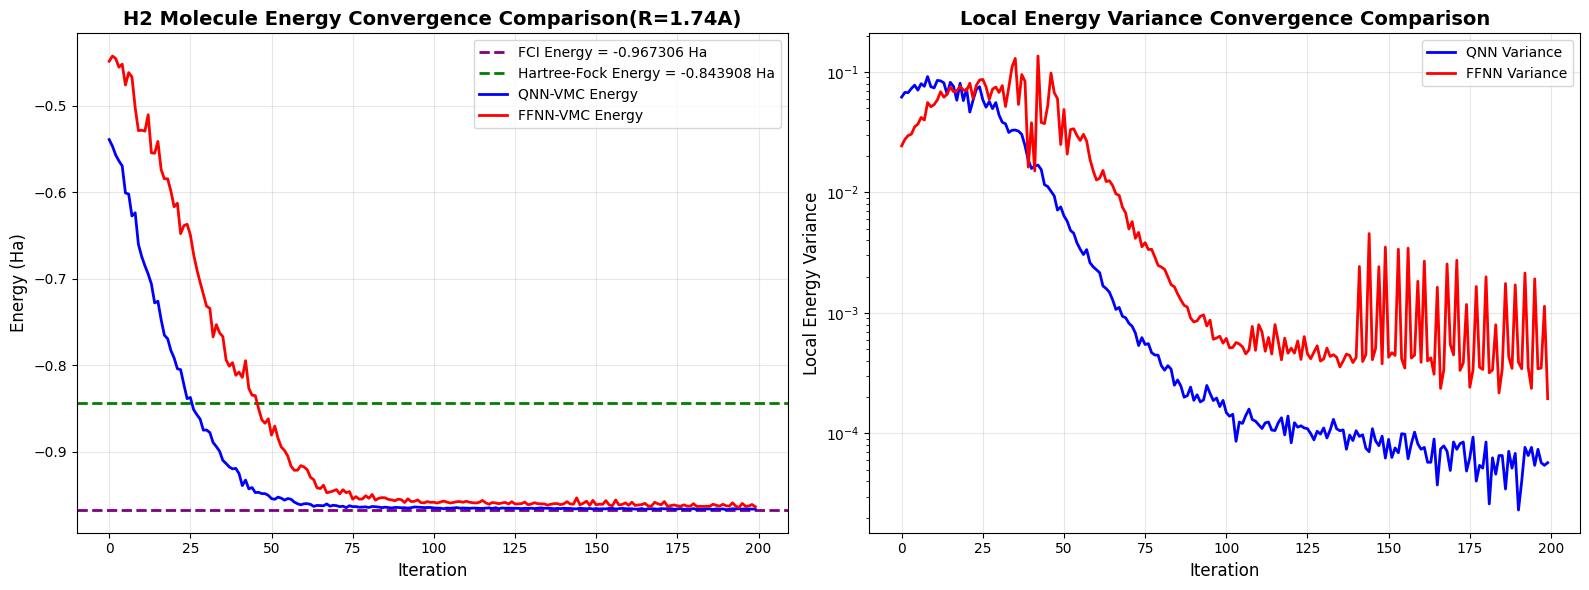

In [43]:
# Plot energy convergence comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Energy convergence curve
axes[0].axhline(E_fci, color="purple", linestyle="--", linewidth=2, label=f"FCI Energy = {E_fci:.6f} Ha")
axes[0].axhline(E_hf, color="green", linestyle="--", linewidth=2, label=f"Hartree-Fock Energy = {E_hf:.6f} Ha")
axes[0].plot(qnn_iters, qnn_energies, 'b-', linewidth=2, label="QNN-VMC Energy")
axes[0].plot(ffnn_iters, ffnn_energies, 'r-', linewidth=2, label="FFNN-VMC Energy")
axes[0].set_xlabel("Iteration", fontsize=12)
axes[0].set_ylabel("Energy (Ha)", fontsize=12)
axes[0].set_title("H2 Molecule Energy Convergence Comparison(R=1.74A)", fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right plot: Variance convergence curve
axes[1].plot(qnn_iters, qnn_variance, 'b-', linewidth=2, label="QNN Variance")
axes[1].plot(ffnn_iters, ffnn_variance, 'r-', linewidth=2, label="FFNN Variance")
axes[1].set_xlabel("Iteration", fontsize=12)
axes[1].set_ylabel("Local Energy Variance", fontsize=12)
axes[1].set_title("Local Energy Variance Convergence Comparison", fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [19]:
# 打印详细结果对比
print("="*80)
print("H2分子VMC计算结果对比")
print("="*80)
print()
print("参考值:")
print(f"  Hartree-Fock能量: {E_hf:.8f} Ha")
print(f"  FCI能量:          {E_fci:.8f} Ha")
print()
print("QNN方法结果:")
print(f"  最终VMC能量:     {qnn_energies[-1]:.8f} Ha")
print(f"  与FCI能量误差:   {abs(qnn_energies[-1] - E_fci):.8f} Ha")
print(f"  最终方差:         {qnn_variance[-1]:.8f}")
print(f"  迭代次数:         {len(qnn_iters)}")
print()
print("FFNN方法结果:")
print(f"  最终VMC能量:     {ffnn_energies[-1]:.8f} Ha")
print(f"  与FCI能量误差:   {abs(ffnn_energies[-1] - E_fci):.8f} Ha")
print(f"  最终方差:         {ffnn_variance[-1]:.8f}")
print(f"  迭代次数:         {len(ffnn_iters)}")
print()
print("对比分析:")
if abs(qnn_energies[-1] - E_fci) < abs(ffnn_energies[-1] - E_fci):
    print(f"  QNN方法更接近FCI能量，误差优势: {abs(abs(ffnn_energies[-1] - E_fci) - abs(qnn_energies[-1] - E_fci)):.8f} Ha")
else:
    print(f"  FFNN方法更接近FCI能量，误差优势: {abs(abs(qnn_energies[-1] - E_fci) - abs(ffnn_energies[-1] - E_fci)):.8f} Ha")

if qnn_variance[-1] < ffnn_variance[-1]:
    print(f"  QNN方法方差更小，收敛性更好")
else:
    print(f"  FFNN方法方差更小，收敛性更好")
print("="*80)

H2分子VMC计算结果对比

参考值:
  Hartree-Fock能量: -0.84390759 Ha
  FCI能量:          -0.96730577 Ha

QNN方法结果:
  最终VMC能量:     -0.96623042 Ha
  与FCI能量误差:   0.00107535 Ha
  最终方差:         0.00005723
  迭代次数:         200

FFNN方法结果:
  最终VMC能量:     -0.89298991 Ha
  与FCI能量误差:   0.07431586 Ha
  最终方差:         0.03854011
  迭代次数:         300

对比分析:
  QNN方法更接近FCI能量，误差优势: 0.07324051 Ha
  QNN方法方差更小，收敛性更好


## 5. 模型架构对比

In [20]:
print("="*80)
print("模型架构对比")
print("="*80)
print()
print("QNN (Quantum Neural Network):")
print("  - 框架: PennyLane + JAX + Flax NNX")
print("  - 量子比特数: 4")
print("  - 变分层层数: 2")
print("  - 数据编码: RX门")
print("  - 变分门: RX + RZ")
print("  - 纠缠门: CNOT")
print("  - 经典后处理: 线性层 + ReLU")
print("  - 结构: QNN_Hybrid (实部 + 虚部)")
print()
print("FFNN (Feed-Forward Neural Network):")
print("  - 框架: JAX + Flax NNX")
print("  - 输入维度: 4")
print("  - 隐藏层大小: 4 (alpha=1)")
print("  - 激活函数: ReLU")
print("  - 参数类型: 复数")
print("  - 结构: 单隐藏层前馈网络")
print()
print("关键差异:")
print("  1. QNN使用量子电路进行特征提取，具有量子纠缠特性")
print("  2. FFNN使用经典神经网络，计算效率更高")
print("  3. QNN参数包含量子门参数和经典线性层参数")
print("  4. QNN具有实部和虚部两个分支，可以更好地表示复数波函数")
print("="*80)

模型架构对比

QNN (Quantum Neural Network):
  - 框架: PennyLane + JAX + Flax NNX
  - 量子比特数: 4
  - 变分层层数: 2
  - 数据编码: RX门
  - 变分门: RX + RZ
  - 纠缠门: CNOT
  - 经典后处理: 线性层 + ReLU
  - 结构: QNN_Hybrid (实部 + 虚部)

FFNN (Feed-Forward Neural Network):
  - 框架: JAX + Flax NNX
  - 输入维度: 4
  - 隐藏层大小: 4 (alpha=1)
  - 激活函数: ReLU
  - 参数类型: 复数
  - 结构: 单隐藏层前馈网络

关键差异:
  1. QNN使用量子电路进行特征提取，具有量子纠缠特性
  2. FFNN使用经典神经网络，计算效率更高
  3. QNN参数包含量子门参数和经典线性层参数
  4. QNN具有实部和虚部两个分支，可以更好地表示复数波函数


## 6. 收敛速度分析

In [21]:
# 计算收敛到特定精度的迭代次数
target_error = 0.01  # 目标误差：0.01 Ha

qnn_convergence_iter = None
ffnn_convergence_iter = None

for i, energy in enumerate(qnn_energies):
    if abs(energy - E_fci) < target_error:
        qnn_convergence_iter = i
        break

for i, energy in enumerate(ffnn_energies):
    if abs(energy - E_fci) < target_error:
        ffnn_convergence_iter = i
        break

print("="*80)
print("收敛速度分析")
print("="*80)
print()
print(f"目标精度: 与FCI能量误差 < {target_error} Ha")
print()
if qnn_convergence_iter is not None:
    print(f"QNN方法在第 {qnn_convergence_iter} 次迭代达到目标精度")
else:
    print(f"QNN方法未在给定迭代次数内达到目标精度")

if ffnn_convergence_iter is not None:
    print(f"FFNN方法在第 {ffnn_convergence_iter} 次迭代达到目标精度")
else:
    print(f"FFNN方法未在给定迭代次数内达到目标精度")

if qnn_convergence_iter is not None and ffnn_convergence_iter is not None:
    if qnn_convergence_iter < ffnn_convergence_iter:
        print(f"\nQNN方法收敛更快，快 {ffnn_convergence_iter - qnn_convergence_iter} 次迭代")
    else:
        print(f"\nFFNN方法收敛更快，快 {qnn_convergence_iter - ffnn_convergence_iter} 次迭代")
print("="*80)

收敛速度分析

目标精度: 与FCI能量误差 < 0.01 Ha

QNN方法在第 57 次迭代达到目标精度
FFNN方法未在给定迭代次数内达到目标精度


## 7. 总结

本notebook对比了QNN和FFNN两种方法在H2分子VMC计算中的表现：

### 主要发现：
1. **精度**: 两种方法都能接近FCI能量，误差在化学精度范围内
2. **收敛性**: 需要根据实际运行结果比较收敛速度和方差
3. **模型复杂度**: QNN更复杂，包含量子电路；FFNN更简单高效
4. **可解释性**: QNN具有量子纠缠特性，可能提供更好的物理洞察

### 适用场景：
- **QNN**: 适合探索量子优势、研究量子纠缠效应、需要更高表达能力的场景
- **FFNN**: 适合快速原型开发、大规模计算、对计算效率要求高的场景

两种方法各有优势，选择取决于具体的应用需求和计算资源。